# ALP - Data Science (CEK)

### Kevin Febrian Setiadi - 0706022410001
### Ethan Cannavaro Lauda - 0706022410002
### Casey Daniella Winarto - 0706022410026

Dataset: Telco Customer Churn (Kaggle) <br>
Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [401]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE

In [402]:
# Show all columns when displaying the dataframe (no column truncation)
pd.set_option('display.max_columns', None)

In [403]:
# Load Dataset
link = 'https://raw.githubusercontent.com/HEHEfebrian/ALPDS/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(link)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Preliminary Analysis

In [404]:
# Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Cleaning

In [405]:
# Check the number of empty string values in each column
df.apply(lambda col: col.astype(str).str.strip().eq("")).sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [406]:
# Check for invalid or unusual string patterns in each column
df.apply(lambda col: col.astype(str).str.contains(r'\\!s\*\$', regex=True)).sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [407]:
# Display rows that contain empty string values
mask = df.apply(lambda col: col.astype(str).str.strip().eq(""))

df[mask.any(axis=1)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [408]:
# Replace empty string values with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

In [409]:
# Fill missing values in TotalCharges using MonthlyCharges × tenure
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

In [410]:
# Recheck for empty string values after replacement
df[mask.any(axis=1)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [411]:
# Convert TotalCharges column to numeric data type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [412]:
# Remove duplicate rows from the dataset
df.drop_duplicates(inplace=True)

In [413]:
# Display descriptive statistics of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## EDA

### Univariate

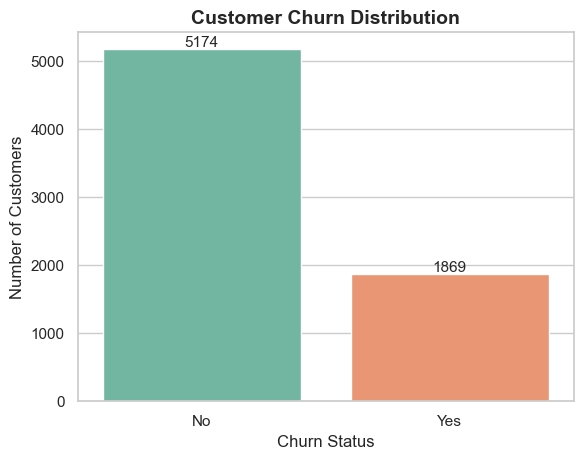

In [414]:
# Visualize customer churn distribution
sns.set_style("whitegrid")

ax = sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )
plt.show()

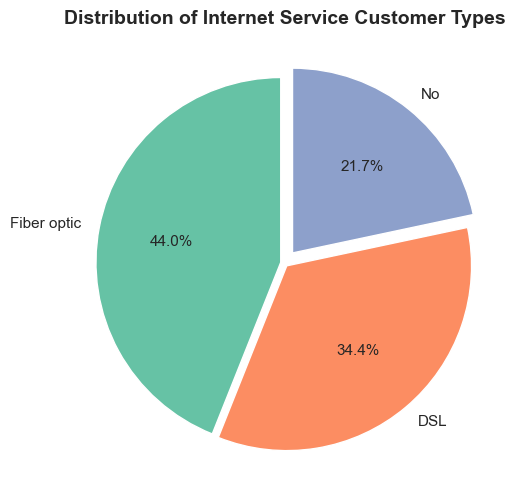

In [415]:
# Visualize the distribution of internet service customer types
data = df['InternetService'].value_counts()

plt.figure(figsize=(10,6))
plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11},
    explode=[0.02, 0.02, 0.07],
    colors=sns.color_palette('Set2')
)
plt.title('Distribution of Internet Service Customer Types', fontsize=14, fontweight='bold')
plt.show()

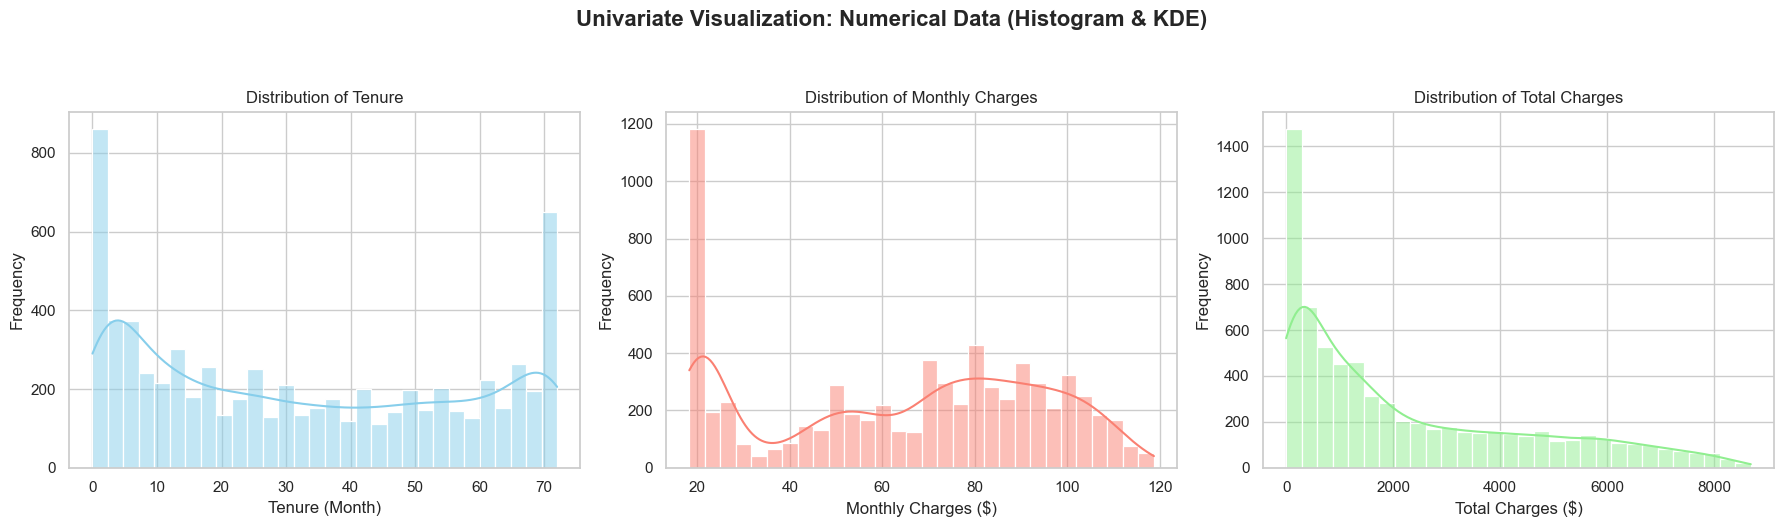

In [416]:
# Visualize the distribution of numerical features using histogram and KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Visualization: Numerical Data (Histogram & KDE)', fontsize=16, fontweight='bold', y=1.05)

# Tenure distribution
sns.histplot(data=df, x='tenure', kde=True, bins=30, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Tenure')
axes[0].set_xlabel('Tenure (Month)')
axes[0].set_ylabel('Frequency')

# Monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', kde=True, bins=30, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Frequency')

# Total charges distribution
sns.histplot(data=df, x='TotalCharges', kde=True, bins=30, color='lightgreen', ax=axes[2])
axes[2].set_title('Distribution of Total Charges')
axes[2].set_xlabel('Total Charges ($)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Multivariate

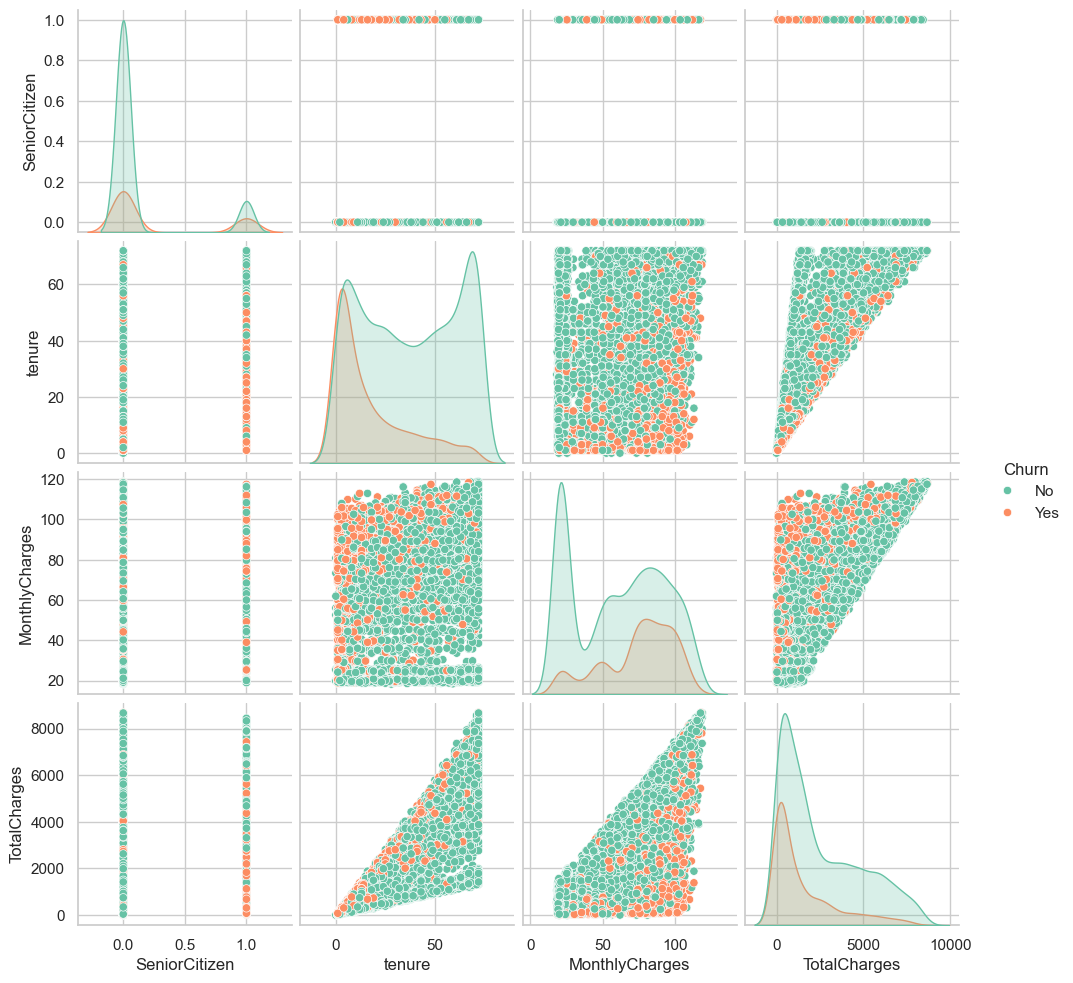

In [417]:
# Visualize relationships between numerical features using pairplot
selected_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges','Churn']
sns.pairplot(df[selected_columns], hue="Churn", palette='Set2')
plt.show()

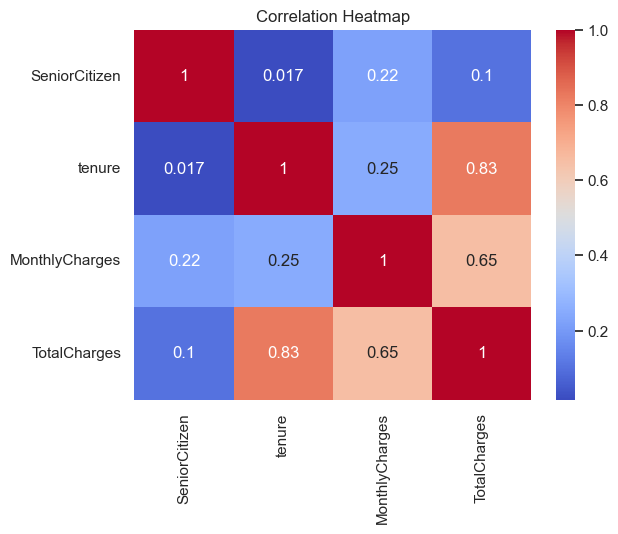

In [418]:
# Visualize correlation between numerical features
sns.heatmap(df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

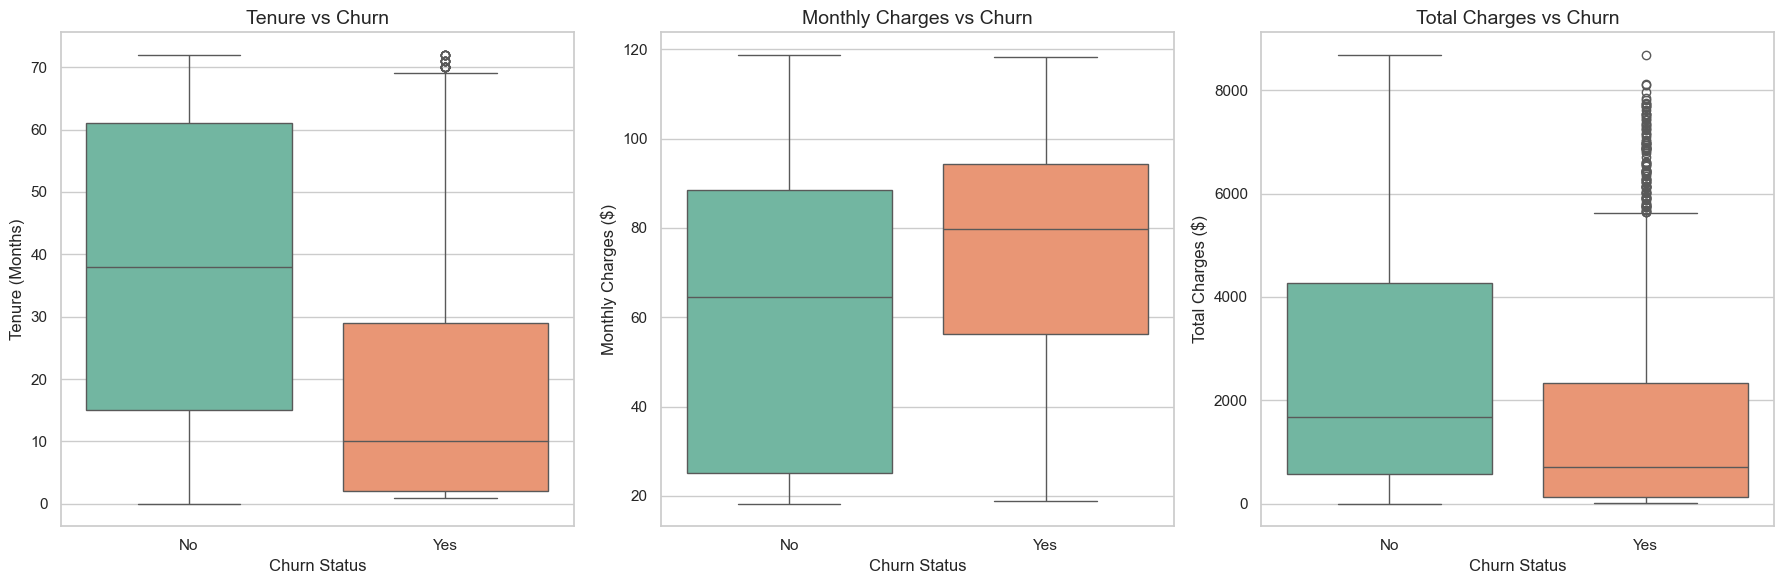

In [419]:
# Compare numerical features based on churn status using boxplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Tenure vs Churn
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Tenure vs Churn", fontsize=14)
axes[0].set_xlabel("Churn Status", fontsize=12)
axes[0].set_ylabel("Tenure (Months)", fontsize=12)

# Monthly Charges vs Churn 
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Monthly Charges vs Churn", fontsize=14)
axes[1].set_xlabel("Churn Status", fontsize=12)
axes[1].set_ylabel("Monthly Charges ($)", fontsize=12)

# Total Charges vs Churn
sns.boxplot(data=df, x="Churn", y="TotalCharges", hue="Churn", ax=axes[2], palette="Set2", legend=False)
axes[2].set_title("Total Charges vs Churn", fontsize=14)
axes[2].set_xlabel("Churn Status", fontsize=12)
axes[2].set_ylabel("Total Charges ($)", fontsize=12)

plt.tight_layout()
plt.show()

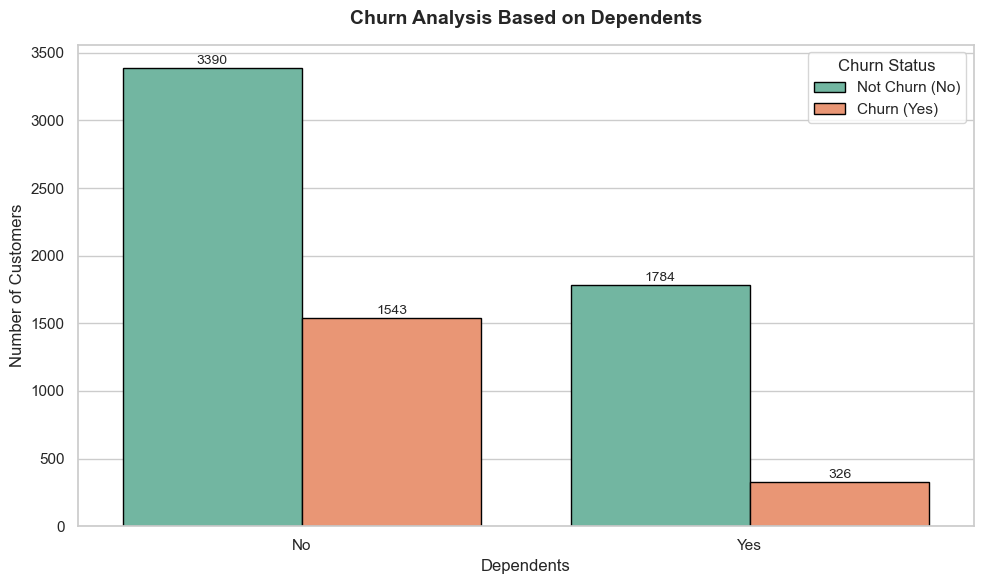

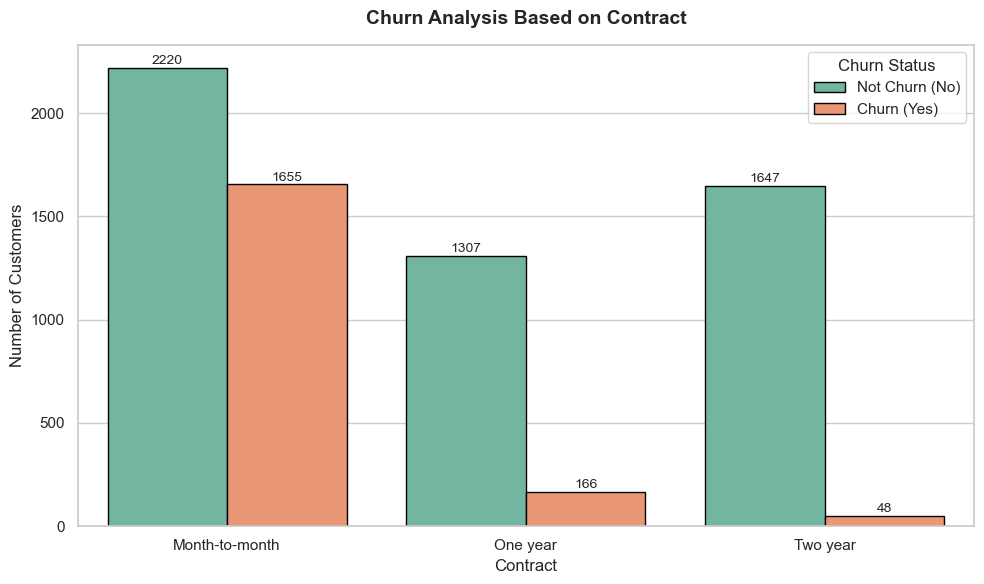

In [420]:
# Analyze churn distribution based on contract type and dependents

features = ["Dependents", "Contract"]

for f in features:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x=f, hue='Churn', palette='Set2', edgecolor='black')
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=10)
    
    plt.title(f'Churn Analysis Based on {f}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(f, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.legend(title='Churn Status', labels=['Not Churn (No)', 'Churn (Yes)'])
    plt.tight_layout()
    plt.show()

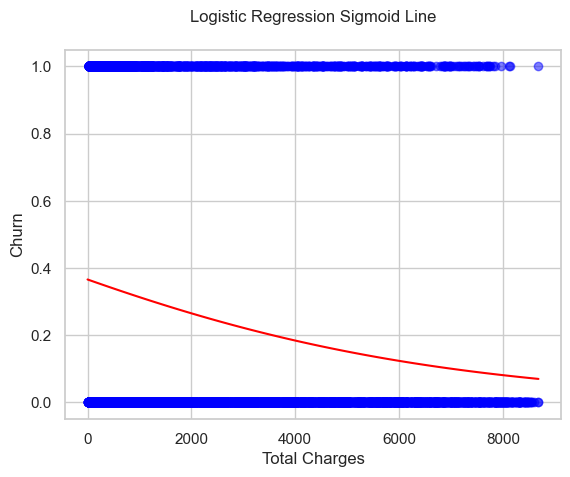

In [421]:
# Visualize the sigmoid curve of Logistic Regression
X_sigmoid = df[['TotalCharges']]
y_sigmoid = df['Churn']
y_sigmoid_numeric = y_sigmoid.map({'Yes': 1, 'No': 0})

modelforvisual = LogisticRegression()
modelforvisual.fit(X_sigmoid, y_sigmoid_numeric)

x_range = np.linspace(df['TotalCharges'].min(), df['TotalCharges'].max(), 100)

sigmoid_func_retail = 1 / (1 + np.exp(-modelforvisual.coef_ * x_range - modelforvisual.intercept_))

plt.plot(x_range, sigmoid_func_retail[0], color='red')
plt.scatter(X_sigmoid, y_sigmoid_numeric, color='blue', alpha=0.5)
plt.title('Logistic Regression Sigmoid Line', pad=20)
plt.xlabel('Total Charges')
plt.ylabel('Churn')
plt.show()

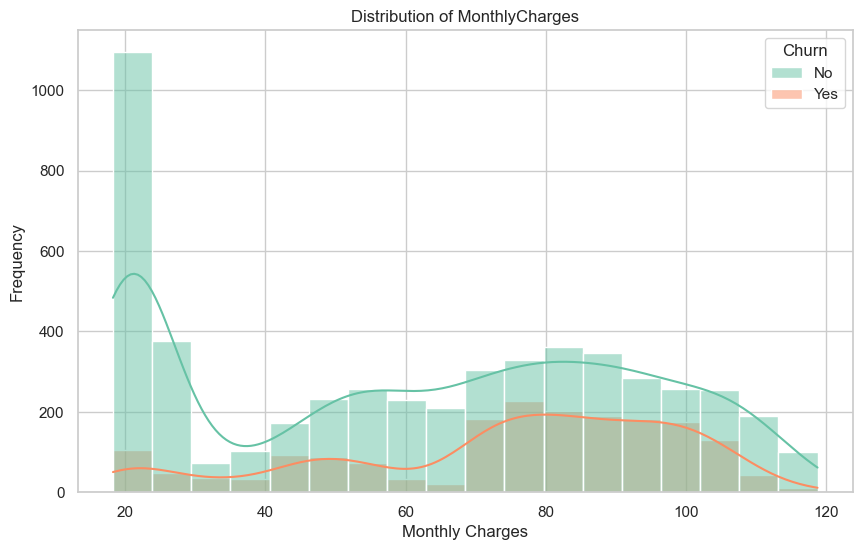

In [422]:
# Visualize the distribution of MonthlyCharges based on churn status
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True, palette='Set2')
plt.title(f"Distribution of MonthlyCharges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

## Data Preprocessing

In [423]:
# Apply standardization scaling to numerical feature columns
scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [424]:
# Encode binary categorical columns into numerical values
binary_cols = [
    'gender','Partner','Dependents',
    'PhoneService','PaperlessBilling','Churn'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Male':1, 'Female':0})

In [425]:
# Apply one-hot encoding to categorical feature columns
df = pd.get_dummies(df, columns=[
    'InternetService',
    'Contract',
    'PaymentMethod',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
], drop_first=True)

In [426]:
# Drop customerID column
df.drop('customerID', axis=1, inplace=True)

In [427]:
# Move the 'Churn' column to the last position in the dataframe
df['Churn'] = df.pop('Churn')

In [428]:
# Convert boolean columns to integer type (0 and 1)
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [429]:
# Display the final processed dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Churn
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.958066,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


## Train Test Split

In [430]:
# Split dataset into training and testing sets
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [431]:
# Add constant
X_train_const = sm.add_constant(X_train)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_const.values, i+1)
    for i in range(len(X_train.columns))
]

print(vif_data)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  Feature           VIF
0                                  gender  1.002473e+00
1                           SeniorCitizen  1.150331e+00
2                                 Partner  1.458444e+00
3                              Dependents  1.380263e+00
4                                  tenure  7.512424e+00
5                            PhoneService           inf
6                        PaperlessBilling  1.213764e+00
7                          MonthlyCharges  8.742996e+02
8                            TotalCharges  1.085479e+01
9             InternetService_Fiber optic  1.499894e+02
10                     InternetService_No  3.467706e+07
11                      Contract_One year  1.635009e+00
12                      Contract_Two year  2.620571e+00
13  PaymentMethod_Credit card (automatic)  1.562759e+00
14         PaymentMethod_Electronic check  1.942289e+00
15             PaymentMethod_Mailed check  1.849030e+00
16         MultipleLines_No phone service       

In [432]:
column_multicol = [
    'MultipleLines_No phone service',
    'InternetService_No',                    
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service',
    'TotalCharges',
    'InternetService_Fiber optic',
    'MultipleLines_Yes',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

X_train_new = X_train.drop(columns=column_multicol)
X_test_new = X_test.drop(columns=column_multicol)

print("After removing multicollinearity:", X_train_new.shape[1])
print("List of remaining columns:\n", X_train_new.columns.tolist())

After removing multicollinearity: 13
List of remaining columns:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [433]:
# Apply SMOTE to handle class imbalance in the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_new, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4138
1    1496
Name: count, dtype: int64

After SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64


## Model Training

In [434]:
# Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [435]:
# Find the k value with the highest accuracy score for K-NN model
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
best_k = 0
best_acc = 0

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_smote, y_train_smote)

    acc = accuracy_score(y_test, knn.predict(X_test_new))

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best k:", best_k)
print("Best accuracy:", best_acc)

Best k: 21
Best accuracy: 0.7217885024840313


In [436]:
# K-NN Model
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_model.fit(X_train_smote, y_train_smote)

KNeighborsClassifier(metric='euclidean', n_neighbors=21)

In [437]:
# Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train_smote, y_train_smote)

GaussianNB()

In [ ]:
# Balance the training data using SMOTE
smote = SMOTE(random_state=42)

X_train_rf, y_train_rf = smote.fit_resample(X_train, y_train)

print("Before Smote:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_rf.value_counts())

Before Smote:
Churn
0    4138
1    1496
Name: count, dtype: int64

After SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64


In [439]:
# Hyperparameter tuning for Random Forest using RandomizedSearchCV
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=skf,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_rf, y_train_rf)

print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best Cross Validation Score: 0.8344210227088815


In [440]:
# Random Forest Model
rf_model = random_search.best_estimator_
rf_model.fit(X_train_rf, y_train_rf)

RandomForestClassifier(max_features='log2', min_samples_leaf=2,
                       n_estimators=200, random_state=42)

## Prediction

In [441]:
# Generate predictions using trained models
y_pred_log = log_model.predict(X_test_new)
y_pred_knn = knn_model.predict(X_test_new)
y_pred_nb = nb_model.predict(X_test_new)
y_pred_rf = rf_model.predict(X_test)

comparison_table = pd.DataFrame({"y_test":y_test, "y_pred_log":y_pred_log, "y_pred_knn":y_pred_knn, "y_pred_nb":y_pred_nb, "y_pred_rf":y_pred_rf})
comparison_table.head()

,y_test,y_pred_log,y_pred_knn,y_pred_nb,y_pred_rf
185,1,1,1,1,1
2715,0,0,0,1,0
3825,0,0,0,0,0
1807,1,1,1,1,1
132,0,0,0,0,0


## Evaluation

In [442]:
# Evaluate Logistic Regression model
cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix using Logistics Regression\n", cm_log)

accuracy_log = accuracy_score(y_test, y_pred_log)
print("Accuracy Score:", accuracy_log)
print("Precision, Recall, F1-Score:\n", classification_report(y_test, y_pred_log))

# Evaluate K-Nearest Neighbors model
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix using K-Nearest Neighbour\n", cm_knn)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy Score:", accuracy_knn)
print("Precision, Recall, F1-Score:\n", classification_report(y_test, y_pred_knn))  

# Evaluate Naive Bayes model
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix using Naive Bayes\n", cm_nb)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy Score:", accuracy_nb)
print("Classification Report using Naive Bayes\n", classification_report(y_test, y_pred_nb))

# Evaluate Random Forest model
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix using Random Forest\n", cm_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Score:", accuracy_rf)
print("Classification Report using Random Forest\n", classification_report(y_test, y_pred_rf))

Confusion Matrix using Logistics Regression
 [[738 298]
 [ 58 315]]
Accuracy Score: 0.7473385379701917
Precision, Recall, F1-Score:
               precision    recall  f1-score   support

           0       0.93      0.71      0.81      1036
           1       0.51      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409


Confusion Matrix using K-Nearest Neighbour
 [[707 329]
 [ 63 310]]
Accuracy Score: 0.7217885024840313
Precision, Recall, F1-Score:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78      1036
           1       0.49      0.83      0.61       373

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.72      0.74      1409


Confusion Matrix using Naive Bayes
 [[682 354]
 [ 49 324]]
Accuracy Score: 0.71

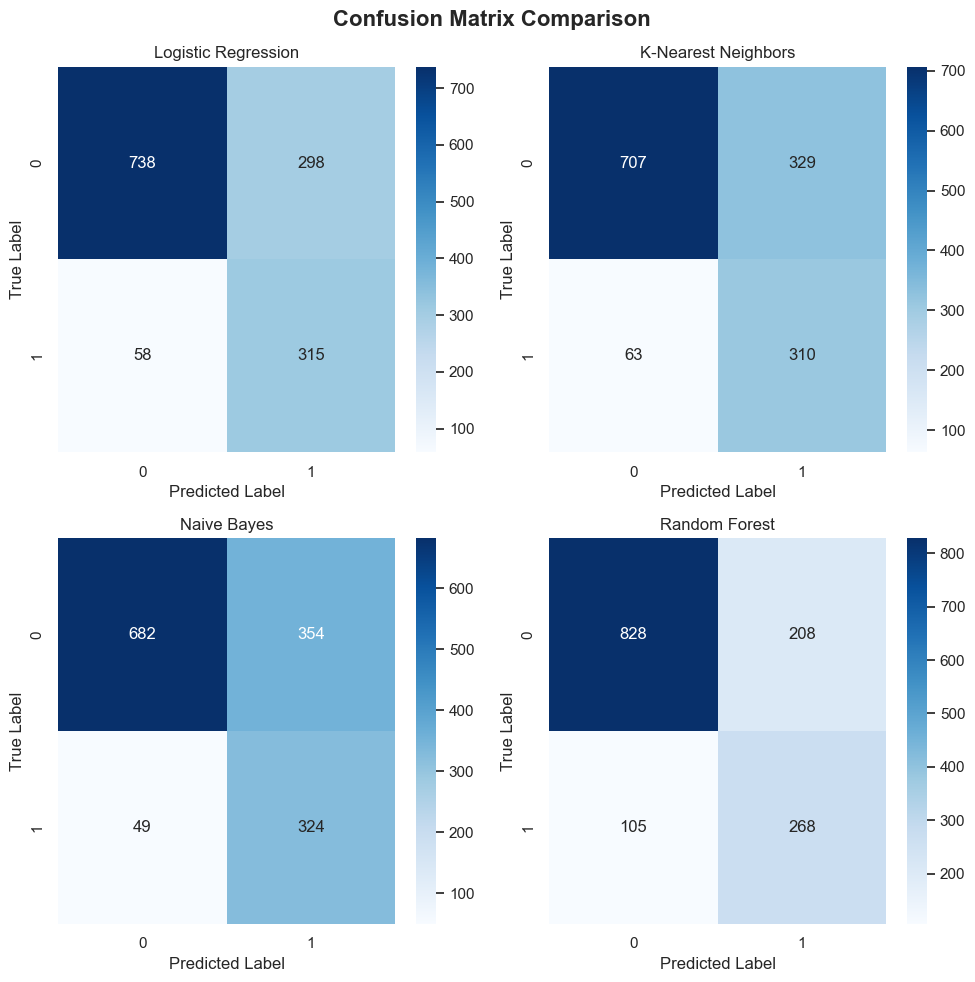

In [443]:
# Visualize confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0])

axes[0, 0].set_title('Logistic Regression')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# K-Nearest Neighbors
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", ax=axes[0, 1])

axes[0, 1].set_title('K-Nearest Neighbors')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# Naive Bayes
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",ax=axes[1, 0])

axes[1, 0].set_title('Naive Bayes')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1])

axes[1, 1].set_title('Random Forest')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

fig.suptitle('Confusion Matrix Comparison', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Based on the evaluation results of the Telco Customer Churn dataset, Random Forest Random Forest achieved the best overall performance among the tested models with the highest accuracy score of 0.7778 or 78% and a balanced performance across precision, recall, and F1-score metrics. Although Naive Bayes Naive Bayes and Logistic Regression Logistic Regression obtained higher recall scores for the churn class, indicating better capability in identifying customers likely to leave the service, their lower precision values resulted in more false positive predictions. Meanwhile, K-Nearest Neighbors showed the lowest overall performance among the models. Therefore, Random Forest can be considered the most effective model in this study due to its ability to provide the best balance between identifying churn customers and maintaining prediction accuracy.